# Natural Language Processing Lab - Assignment 1


In [ ]:
# Install/import required packages
!pip -q install openpyxl wordcloud librosa

import os, re, json, zipfile, wave
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from IPython.display import display, Audio, Video
from wordcloud import WordCloud

plt.style.use('seaborn-v0_8-whitegrid')
DATA_DIR = 'nlp_lab_data'
os.makedirs(DATA_DIR, exist_ok=True)

## Task 1 - Read and visualize different data formats

In [ ]:
# Download/readable example datasets and create local copies in multiple formats.
df = pd.DataFrame({
    'category': ['AI', 'NLP', 'Vision', 'AI', 'NLP'],
    'score': [82, 91, 76, 88, 95],
    'samples': [120, 150, 90, 130, 170]
})
df.to_csv(f'{DATA_DIR}/sample.csv', index=False)
df.to_csv(f'{DATA_DIR}/sample.tsv', sep='\t', index=False)
df.to_excel(f'{DATA_DIR}/sample.xlsx', index=False)
with open(f'{DATA_DIR}/sample.json', 'w') as f: json.dump(df.to_dict(orient='records'), f, indent=2)
with open(f'{DATA_DIR}/sample.xml', 'w') as f:
    f.write('<records>' + ''.join(f'<record><category>{r.category}</category><score>{r.score}</score></record>' for r in df.itertuples()) + '</records>')
df.to_pickle(f'{DATA_DIR}/sample.pkl')
np.save(f'{DATA_DIR}/sample.npy', df['score'].to_numpy())
np.savez(f'{DATA_DIR}/sample.npz', scores=df['score'].to_numpy(), samples=df['samples'].to_numpy())
with open(f'{DATA_DIR}/sample.txt', 'w') as f: f.write('Natural language processing studies how computers understand human language.')
with zipfile.ZipFile(f'{DATA_DIR}/sample.zip', 'w') as z: z.write(f'{DATA_DIR}/sample.csv', arcname='sample.csv')
print('Example files created in', DATA_DIR)

Example files created in nlp_lab_data


In [ ]:
# Read tabular, interchange, and binary data formats
csv_data = pd.read_csv(f'{DATA_DIR}/sample.csv')
tsv_data = pd.read_csv(f'{DATA_DIR}/sample.tsv', sep='\t')
xlsx_data = pd.read_excel(f'{DATA_DIR}/sample.xlsx')
json_data = pd.read_json(f'{DATA_DIR}/sample.json')
xml_data = pd.read_xml(f'{DATA_DIR}/sample.xml')
pkl_data = pd.read_pickle(f'{DATA_DIR}/sample.pkl')
npy_data = np.load(f'{DATA_DIR}/sample.npy')
npz_data = np.load(f'{DATA_DIR}/sample.npz')
with open(f'{DATA_DIR}/sample.txt') as f: txt_data = f.read()

for name, obj in {'CSV':csv_data, 'TSV':tsv_data, 'XLSX':xlsx_data, 'JSON':json_data, 'XML':xml_data, 'PKL':pkl_data, 'NPY':npy_data, 'TXT':txt_data}.items():
    shape = getattr(obj, 'shape', 'N/A')
    size = getattr(obj, 'size', len(obj) if hasattr(obj, '__len__') else 'N/A')
    print(f'{name:5} | type={type(obj).__name__:12} | size={size} | shape={shape}')
print('NPZ arrays:', npz_data.files)

CSV   | type=DataFrame    | size=15 | shape=(5, 3)
TSV   | type=DataFrame    | size=15 | shape=(5, 3)
XLSX  | type=DataFrame    | size=15 | shape=(5, 3)
JSON  | type=DataFrame    | size=15 | shape=(5, 3)
XML   | type=DataFrame    | size=10 | shape=(5, 2)
PKL   | type=DataFrame    | size=15 | shape=(5, 3)
NPY   | type=ndarray      | size=5 | shape=(5,)
TXT   | type=str          | size=76 | shape=N/A
NPZ arrays: ['scores', 'samples']


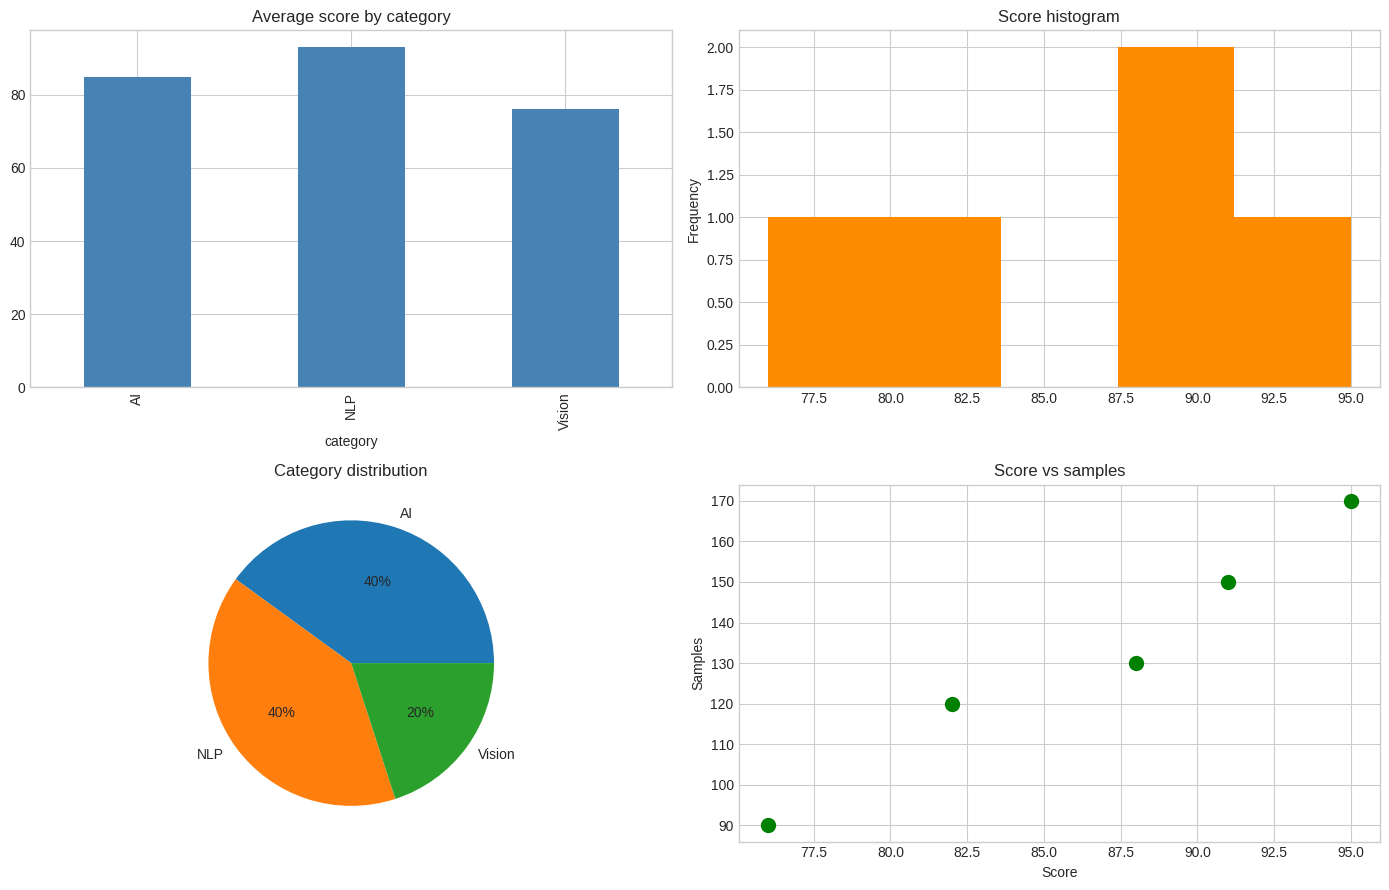

In [ ]:
# Table visualizations
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
df.groupby('category')['score'].mean().plot(kind='bar', ax=axes[0,0], color='steelblue', title='Average score by category')
df['score'].plot(kind='hist', bins=5, ax=axes[0,1], color='darkorange', title='Score histogram')
df['category'].value_counts().plot(kind='pie', autopct='%1.0f%%', ax=axes[1,0], title='Category distribution')
axes[1,0].set_ylabel('')
axes[1,1].scatter(df['score'], df['samples'], s=100, color='green')
axes[1,1].set(title='Score vs samples', xlabel='Score', ylabel='Samples')
plt.tight_layout(); plt.show()

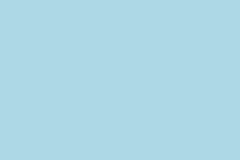

In [ ]:
# Image and audio examples (video/audio files may be uploaded to Colab and displayed with the same functions)
img = Image.new('RGB', (240, 160), 'lightblue')
img.save(f'{DATA_DIR}/sample.png')
display(img)

rate, seconds = 16000, 1
t = np.linspace(0, seconds, rate, endpoint=False)
audio = (0.3*np.sin(2*np.pi*440*t)*32767).astype(np.int16)
with wave.open(f'{DATA_DIR}/sample.wav', 'wb') as wf:
    wf.setnchannels(1); wf.setsampwidth(2); wf.setframerate(rate); wf.writeframes(audio.tobytes())
display(Audio(f'{DATA_DIR}/sample.wav'))

# For an uploaded MP4/AVI file, use: display(Video('/content/your_video.mp4', embed=True))

## Task 2 - Text cleaning

In [ ]:
paragraphs = [
"OMG!! I can't believe I found this aWesoMe article about AI & machine leanring!! It was soooo gooood lol. I <3 nlp butttt i hate spelng errors in textttt. This is gonna be a looong paragraph with looooots of spacesss and weirddddd symbols @#$%. The website's link is www.example.com//// Check it out ASAP!!! #excited",
"Oh my gosh!!! Like, I can't even believe what I just stumbled upon on the world wide web. This article, 'The Marvels of Artificial General Intelligence & the Future of Humanity,' totally blew my mindddd!! It was, like, sooo mind-blowingly awesome, lolz. I mean, I <3 NLP butttt those annoying typos in texts drive me nuts. Brace yourselves, this is gonna be one seriously long paragraph with tons and tons of extraterrestrial spaces and some seriously weird symbols like @#$%. And guess what? The link to the website is www.incrediblenews.com//// So, um, you better check it out like ASAP!!! #excitedmuch",
"yaaayyyy!!! just watched thisssss AMAZZZING vid on AI & how it's changin' evrythinggg!! it waz soooo dopeee, i can't even... lolzzz! #blessed #mindblownn... btw, the link is http://coolai.stuff.com//// totally worthhh ittttttt @@@!!! i <3 tech so much but sometimes it's likee realllyyy confusingggg!!!",
"nooo waayyyyy!!!! this is, like, the 1000000th time i've seen ppl mess up spellings in their blogssss i mean c'mon, u're writing abt deep learning, not sum joke topic anywayzzzz... the article was kinda cooool butttt had lotsa weird $$$%%%@@ symbols all over. you can read it @ www.badblogger.ai//// and let me knw ur thots ASAP!!!",
"heyyyyy, did u read that crazyyyyyyy article on quantum stuff & ai?? like for realll... it wuz crazzzzy detailed but sooooo complicateddd!!! i cud barely undrstnd half of it. the diagrams were fire though!!! i found it here - www.quantmgeekzz.net//// ... plz plz plz read n tell me what u thinkk #toomuchinfo #brainhurts @@@!!!"
]

In [ ]:
def clean_text_stepwise(text):
    # 1. Lowercase
    text = text.lower()
    # 2-3. Expand contractions and the heart symbol
    replacements = {"can't": 'cannot', "it's": 'it is', "i've": 'i have', "i'm": 'i am', "u're": 'you are', "c'mon": 'come on', '<3': 'love'}
    for old, new in replacements.items(): text = text.replace(old, new)
    # 4. Remove URL artifacts and special characters
    text = re.sub(r'https?://\S+|www\.\S+', ' ', text)
    text = re.sub(r'[^a-z0-9\s]', ' ', text)
    # 5. Reduce duplicate letters, then normalize whitespace/punctuation
    text = re.sub(r'(.)\1{2,}', r'\1\1', text)
    text = re.sub(r'\s+', ' ', text).strip()
    # Spelling/slang corrections required by the supplied assignment text
    corrections = {'leanring':'learning','spelng':'spelling','evrythinggg':'everything','waz':'was','changin':'changing','ppl':'people','cmon':'come on','ure':'you are','abt':'about','sum':'some','lotsa':'lots of','knw':'know','thots':'thoughts','cud':'could','undrstnd':'understand','plz':'please','yaaayyyy':'yay','mindblownn':'mindblown'}
    return ' '.join(corrections.get(w, w) for w in text.split())

cleaned_paragraphs = [clean_text_stepwise(p) for p in paragraphs]
for i, text in enumerate(cleaned_paragraphs, 1):
    print(f'Paragraph {i} cleaned text:\n{text}\n')

# The following checks document the required transformations.
assert all('www.' not in p and '@' not in p and '#' not in p for p in cleaned_paragraphs)
assert 'cannot' in cleaned_paragraphs[0] and 'love' in cleaned_paragraphs[0]

Paragraph 1 cleaned text:
omg i cannot believe i found this awesome article about ai machine learning it was soo good lol i love nlp butt i hate spelling errors in textt this is gonna be a loong paragraph with loots of spacess and weirdd symbols the website s link is check it out asap excited

Paragraph 2 cleaned text:
oh my gosh like i cannot even believe what i just stumbled upon on the world wide web this article the marvels of artificial general intelligence the future of humanity totally blew my mindd it was like soo mind blowingly awesome lolz i mean i love nlp butt those annoying typos in texts drive me nuts brace yourselves this is gonna be one seriously long paragraph with tons and tons of extraterrestrial spaces and some seriously weird symbols like and guess what the link to the website is so um you better check it out like asap excitedmuch

Paragraph 3 cleaned text:
yaayy just watched thiss amazzing vid on ai how it is changing evrythingg it was soo dopee i cannot even lolz

## Brown Corpus: tokenization and frequency visualization

In [ ]:
import nltk
nltk.download('brown'); nltk.download('punkt'); nltk.download('punkt_tab'); nltk.download('wordnet'); nltk.download('omw-1.4')
from nltk.corpus import brown
from nltk.tokenize import word_tokenize
from nltk.probability import FreqDist

category = 'news'
brown_text = ' '.join(brown.words(categories=category))
tokens = [w.lower() for w in word_tokenize(brown_text) if w.isalpha()]
freq = FreqDist(tokens)
print('Category:', category, '| Tokens:', len(tokens), '| Unique words:', len(freq))
print(freq.most_common(20))

[nltk_data] Downloading package brown to /root/nltk_data...
[nltk_data]   Unzipping corpora/brown.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


Category: news | Tokens: 84650 | Unique words: 11246
[('the', 6386), ('of', 2861), ('and', 2186), ('to', 2144), ('a', 2139), ('in', 2020), ('for', 969), ('that', 843), ('is', 740), ('was', 720), ('on', 691), ('he', 658), ('at', 636), ('with', 567), ('be', 526), ('as', 517), ('by', 504), ('it', 504), ('his', 428), ('said', 406)]


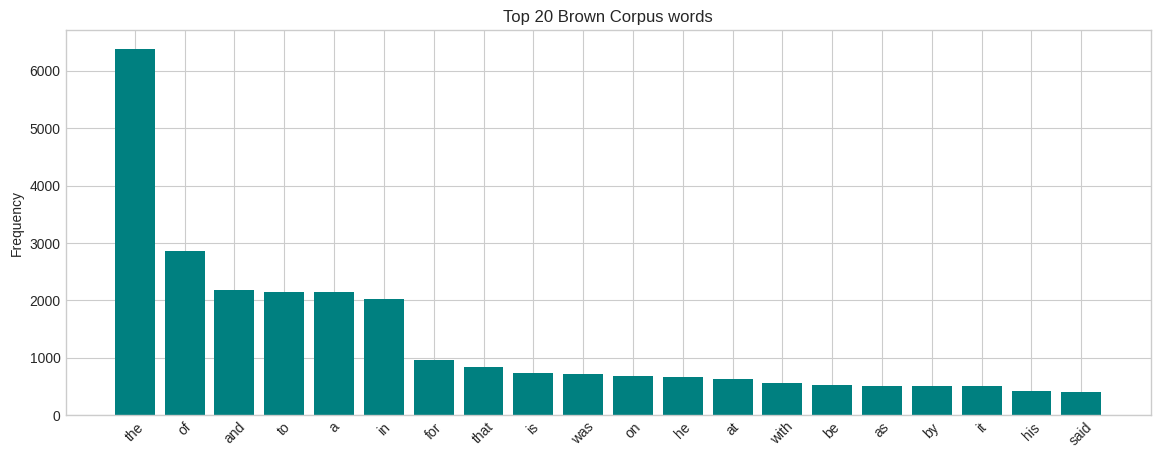

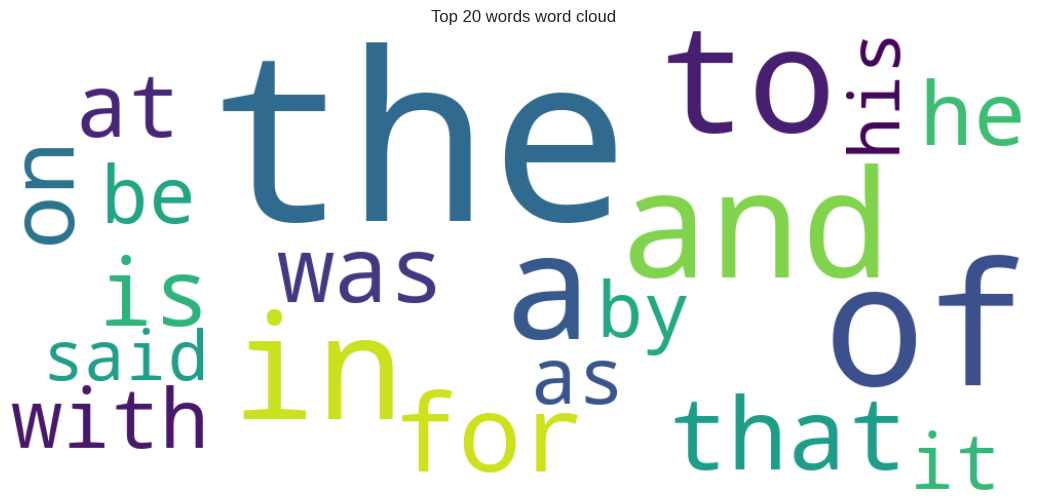

In [ ]:
top20 = freq.most_common(20)
words, counts = zip(*top20)
plt.figure(figsize=(14,5)); plt.bar(words, counts, color='teal'); plt.xticks(rotation=45); plt.title('Top 20 Brown Corpus words'); plt.ylabel('Frequency'); plt.show()
wc = WordCloud(width=1000, height=450, background_color='white').generate_from_frequencies(dict(top20))
plt.figure(figsize=(14,6)); plt.imshow(wc, interpolation='bilinear'); plt.axis('off'); plt.title('Top 20 words word cloud'); plt.show()

In [ ]:
from nltk.stem import PorterStemmer, WordNetLemmatizer
stemmer = PorterStemmer(); lemmatizer = WordNetLemmatizer()
stems = [stemmer.stem(w) for w in tokens]
lemmas = [lemmatizer.lemmatize(w) for w in tokens]
stem_freq = FreqDist(stems); lemma_freq = FreqDist(lemmas)
print('Top 20 stemmed words:'); print(stem_freq.most_common(20))
print('Top 20 lemmatized words:'); print(lemma_freq.most_common(20))

Top 20 stemmed words:
[('the', 6386), ('of', 2861), ('and', 2186), ('to', 2144), ('a', 2139), ('in', 2020), ('for', 969), ('that', 843), ('is', 740), ('wa', 720), ('on', 691), ('it', 682), ('he', 658), ('at', 636), ('be', 583), ('with', 567), ('as', 517), ('by', 504), ('hi', 428), ('said', 406)]
Top 20 lemmatized words:
[('the', 6386), ('of', 2861), ('a', 2656), ('and', 2186), ('to', 2144), ('in', 2020), ('for', 969), ('that', 843), ('is', 740), ('wa', 720), ('on', 691), ('it', 682), ('he', 658), ('at', 636), ('with', 567), ('be', 526), ('by', 504), ('his', 428), ('said', 406), ('will', 389)]


,word,raw_count,stem_count,lemma_count
0,the,6386,6386,6386
1,of,2861,2861,2861
2,and,2186,2186,2186
3,to,2144,2144,2144
4,a,2139,2139,2656
5,in,2020,2020,2020
6,for,969,969,969
7,that,843,843,843
8,is,740,740,740
9,was,720,720,720


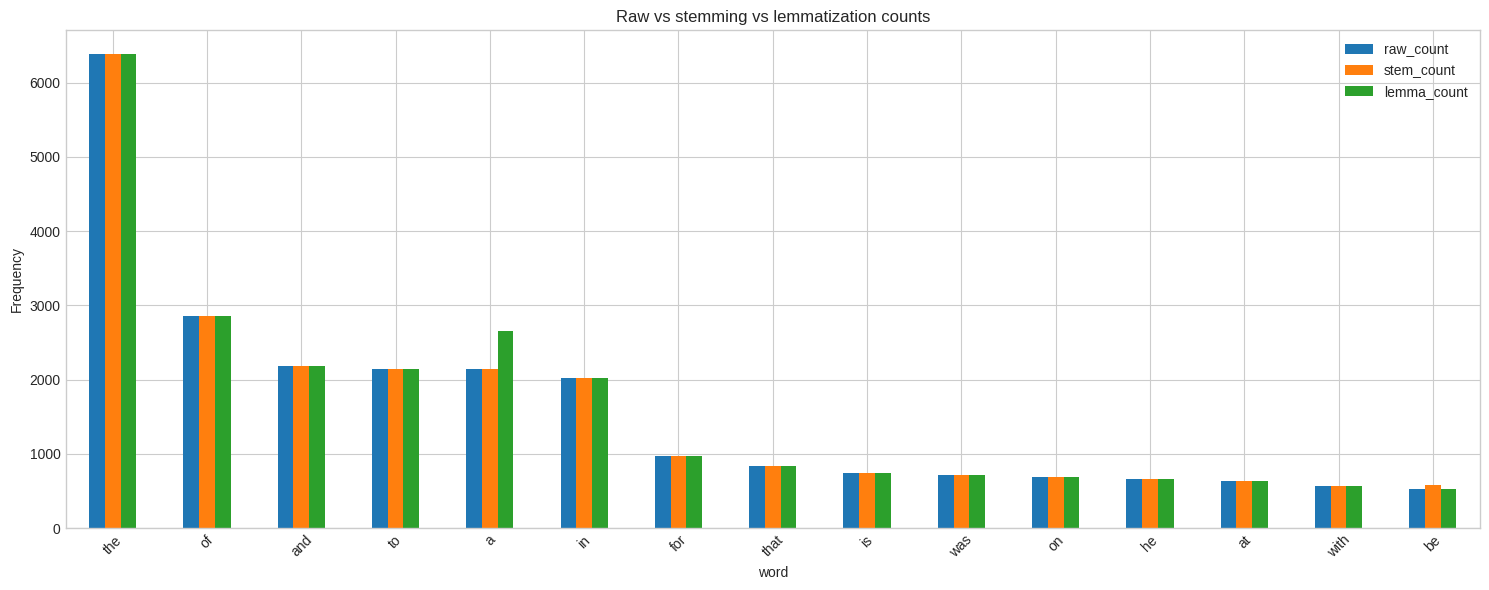

In [ ]:
# Side-by-side comparison for at least 15 frequent words
comparison_words = [w for w, _ in freq.most_common(20)][:15]
comparison = pd.DataFrame({
    'word': comparison_words,
    'raw_count': [freq[w] for w in comparison_words],
    'stem_count': [stem_freq[stemmer.stem(w)] for w in comparison_words],
    'lemma_count': [lemma_freq[lemmatizer.lemmatize(w)] for w in comparison_words]
})
display(comparison)
comparison.set_index('word')[['raw_count','stem_count','lemma_count']].plot(kind='bar', figsize=(15,6), title='Raw vs stemming vs lemmatization counts')
plt.ylabel('Frequency'); plt.xticks(rotation=45); plt.tight_layout(); plt.show()